###importarea de Bibliotecă

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Importarea de datesetul și vizualizarea


In [19]:
df_ml = pd.read_csv("/content/emag_phones_ml_ready.csv")

In [20]:
df_ml.head()

,price,storage,ram,battery,screen_megapixels,screen_size,charger,rating,brand_Allview,brand_Apple,...,brand_Redmi,brand_Rugged,brand_Samsung,brand_Soyes,brand_Tcl,brand_Tecno,brand_Unihertz,brand_Vivo,brand_Xiaomi,brand_Zte
0,795.99,4.0,256.0,6500.0,1.16,6.6,1,4.60,False,False,...,False,False,False,False,False,False,False,False,False,False
1,550.53,4.0,128.0,5000.0,2.53,6.7,0,4.64,False,False,...,False,False,True,False,False,False,False,False,False,False
2,1269.99,8.0,256.0,5000.0,2.53,6.7,0,4.65,False,False,...,False,False,True,False,False,False,False,False,False,False
3,795.99,16.0,256.0,6500.0,1.16,6.6,1,4.60,False,False,...,False,False,False,False,False,False,False,False,False,False
4,586.75,4.0,128.0,5000.0,2.53,6.7,0,4.64,False,False,...,False,False,True,False,False,False,False,False,False,False


###ștergerea duplicare

In [21]:
df_ml = df_ml.drop_duplicates()
print("Număr de rânduri după eliminarea duplicatelor:", len(df_ml))

Număr de rânduri după eliminarea duplicatelor: 957


#### --- Vizualizări inițiale ---

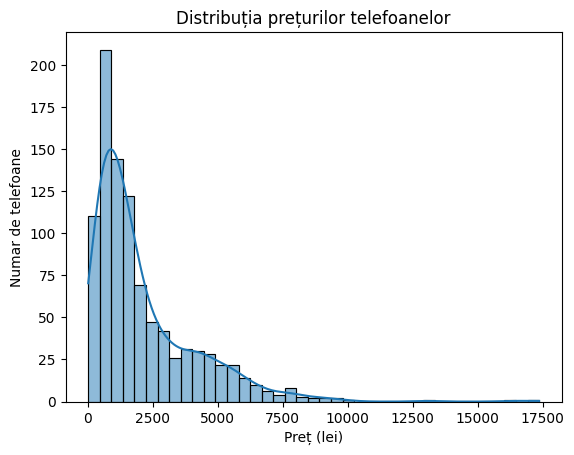

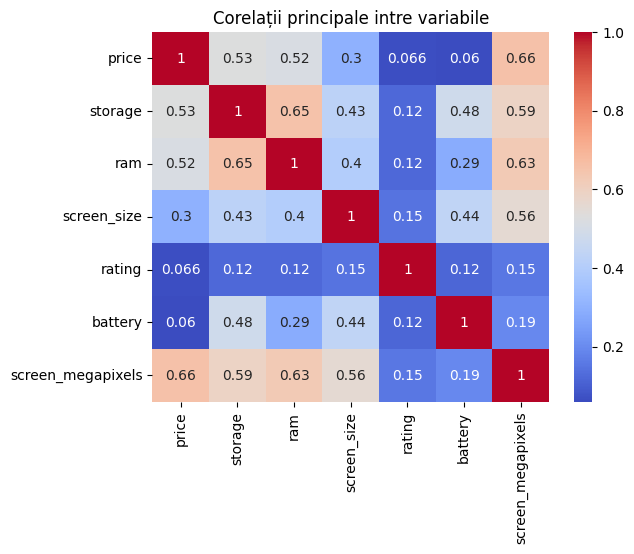

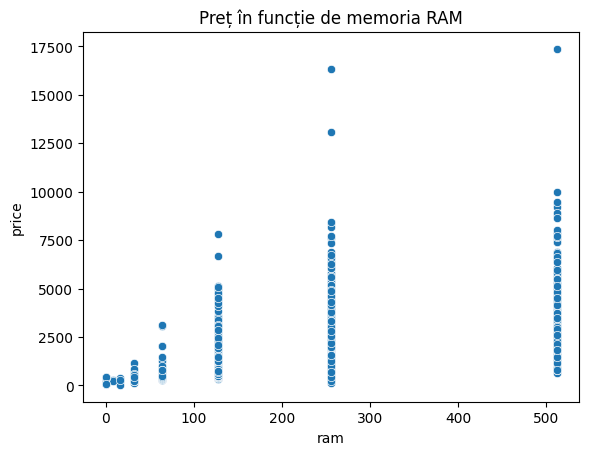

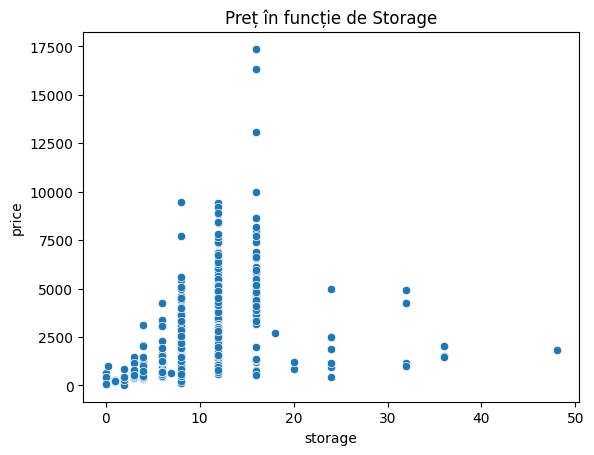

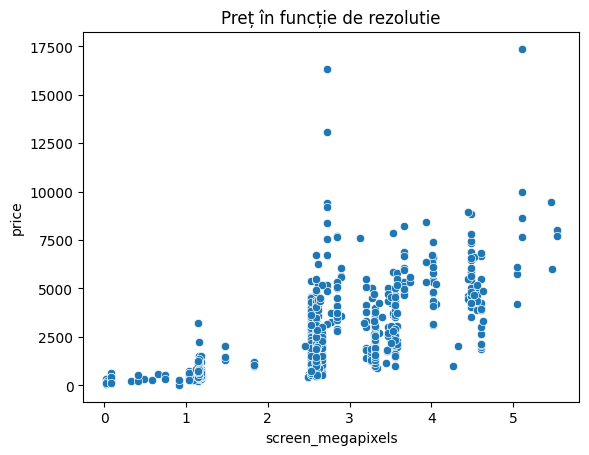

In [22]:
# --- Vizualizări inițiale ---
plt.figure()
sns.histplot(df_ml['price'], kde=True)
plt.title("Distribuția prețurilor telefoanelor")
plt.xlabel("Preț (lei)")
plt.ylabel("Numar de telefoane")
plt.show()

plt.figure()
sns.heatmap(df_ml[['price', 'storage', 'ram', "screen_size", "rating", "battery", "screen_megapixels"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Corelații principale intre variabile")
plt.show()

plt.figure()
sns.scatterplot(data=df_ml, x="ram", y="price")
plt.title("Preț în funcție de memoria RAM")
plt.show()

plt.figure()
sns.scatterplot(data=df_ml, x="storage", y="price")
plt.title("Preț în funcție de Storage")
plt.show()

plt.figure()
sns.scatterplot(data=df_ml, x="screen_megapixels", y="price")
plt.title("Preț în funcție de rezolutie")
plt.show()

#### --- Analiză comparativă între branduri ---

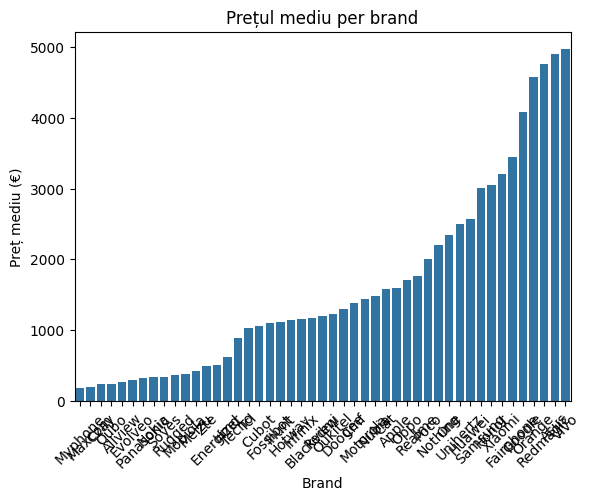

In [23]:
# --- Analiză comparativă între branduri ---
brand_cols = [col for col in df_ml.columns if col.startswith("brand_")]
df_ml['brand'] = df_ml[brand_cols].idxmax(axis=1).str.replace('brand_', '')
df_ml['brand_original'] = df_ml['brand']  # păstrăm pentru vizualizare și top

brand_price_mean = df_ml.groupby('brand')['price'].mean().sort_values()
plt.figure()
sns.barplot(x=brand_price_mean.index, y=brand_price_mean.values)
plt.title("Prețul mediu per brand")
plt.xlabel("Brand")
plt.ylabel("Preț mediu (€)")
plt.xticks(rotation=45)
plt.show()

#### --- Clustering KMeans ---

In [24]:
# --- Clustering KMeans ---
features_cluster = ['price', 'storage', 'ram', 'screen_size', 'rating', 'battery', 'screen_megapixels']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[features_cluster])

kmeans = KMeans(n_clusters=3, random_state=42)
df_ml['cluster'] = kmeans.fit_predict(X_scaled)

### PCA pentru vizualizare

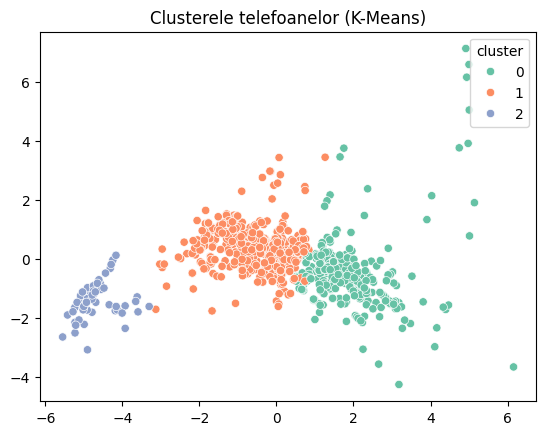

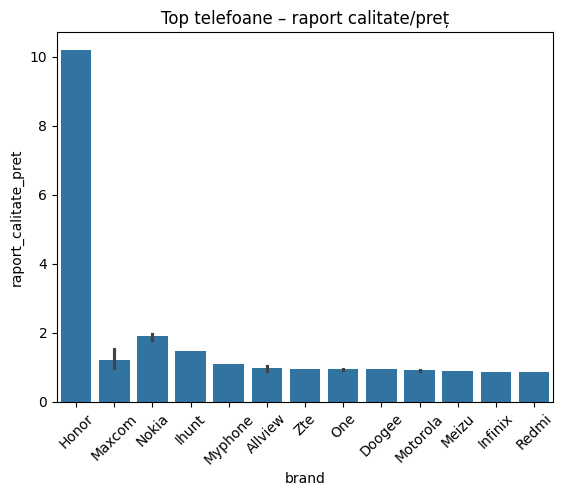

In [25]:
# PCA pentru vizualizare
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure()
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_ml['cluster'], palette='Set2')
plt.title("Clusterele telefoanelor (K-Means)")
plt.show()

# --- Scor calitate și raport calitate/preț ---
for col in ["storage", "ram", "battery", "screen_megapixels", "screen_size", "rating"]:
    df_ml[col + "_norm"] = (df_ml[col] - df_ml[col].min()) / (df_ml[col].max() - df_ml[col].min())

df_ml["scor_calitate"] = (
    0.20 * df_ml["ram_norm"] +
    0.25 * df_ml["storage_norm"] +
    0.15 * df_ml["battery_norm"] +
    0.15 * df_ml["rating_norm"] +
    0.10 * df_ml["screen_size_norm"] +
    0.15 * df_ml["screen_megapixels_norm"]
)

df_ml["raport_calitate_pret"] = (df_ml["scor_calitate"] / df_ml["price"]) * 1000
top_perf = df_ml.sort_values("raport_calitate_pret", ascending=False).head(30)

plt.figure()
sns.barplot(x="brand", y="raport_calitate_pret", data=top_perf)
plt.title("Top telefoane – raport calitate/preț")
plt.xticks(rotation=45)
plt.show()

###--- Pregătire date pentru ML ---

In [26]:
# --- Pregătire date pentru ML ---
df_model = df_ml.copy()

# Coloane textuale pentru get_dummies (excluzând brand_original)
categorical_cols = df_model.select_dtypes(include=['object']).columns
categorical_cols = [c for c in categorical_cols if c != 'brand_original']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

###Variabile explicative și target

In [27]:
# Variabile explicative și target
X = df_model.drop(columns=['price', 'brand_original', 'scor_calitate', 'raport_calitate_pret', "cluster", "storage",
                           "ram", "battery", "screen_megapixels", "screen_size", "rating"])
y = df_model['price']

###Împărțire train/test

In [28]:
# Împărțire train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### --- Modele ML ---


--- Random Forest ---
MAE: 453.0024438387688
RMSE: 786.113316822382
R² train: 0.9562887641437814
R² test: 0.7894036093110319
🔹 Telefoane subevaluate:
    brand_original     price  Random Forest_pred    diferenta
260          Honor  17369.39        12321.965891 -5047.424109
579        Samsung   7696.00         3479.539342 -4216.460658
299        Samsung   8835.00         5464.849438 -3370.150562
679       Motorola   7657.24         4500.325541 -3156.914459
267        Samsung   5428.53         2351.387641 -3077.142359
245        Samsung   5399.99         2771.545867 -2628.444133
372        Samsung  16332.58        13895.846643 -2436.733357
704         Huawei   5499.45         3282.038874 -2217.411126
593        Samsung   4418.92         2287.277903 -2131.642097
689         Google   3494.70         1578.916154 -1915.783846
🔹 Telefoane supraevaluate:
    brand_original    price  Random Forest_pred    diferenta
663          Honor  8650.00        12321.965891  3671.965891
371           Poco

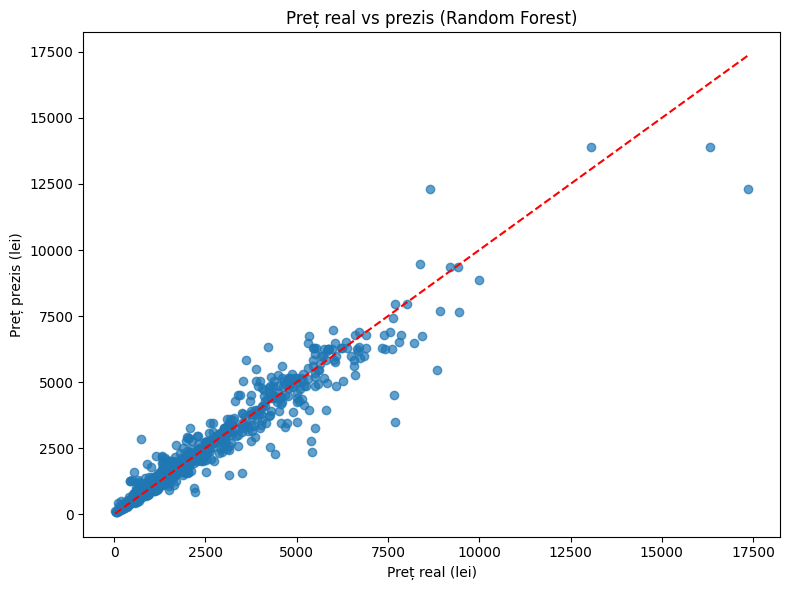

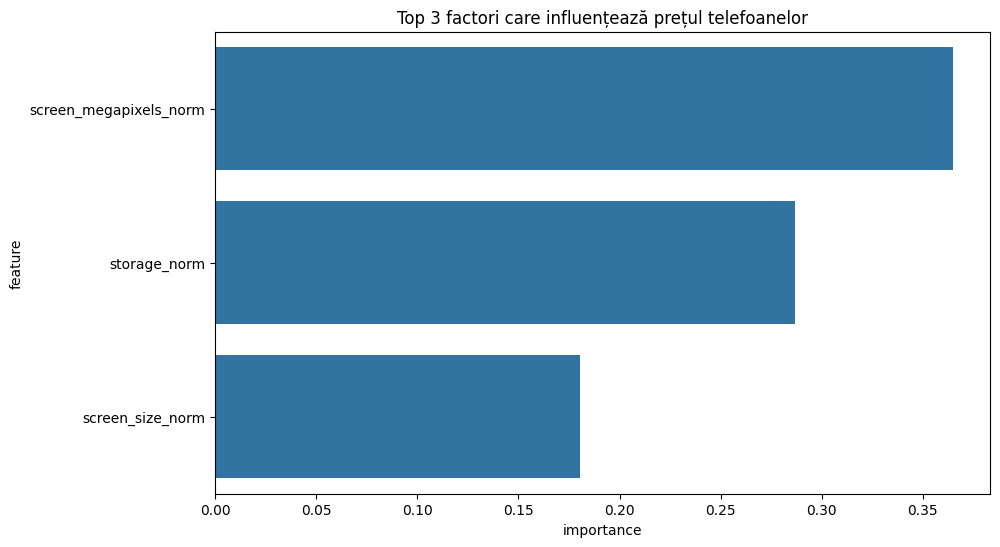

🔄 CROSS-VALIDATION (5-fold):
R² per fold: [0.73574465 0.66574543 0.83372031 0.75141771 0.79096163]
R² mediu: 0.7555
Std dev: 0.0563

--- Gradient Boosting ---
MAE: 514.6063687233061
RMSE: 848.5951144740163
R² train: 0.9401936137712089
R² test: 0.7545959807606551
🔹 Telefoane subevaluate:
    brand_original     price  Gradient Boosting_pred    diferenta
260          Honor  17369.39            13018.817190 -4350.572810
579        Samsung   7696.00             3403.266862 -4292.733138
267        Samsung   5428.53             2067.871441 -3360.658559
245        Samsung   5399.99             2065.989285 -3334.000715
679       Motorola   7657.24             4385.437621 -3271.802379
299        Samsung   8835.00             5563.291715 -3271.708285
593        Samsung   4418.92             2084.693317 -2334.226683
476          Honor   5804.31             3501.329385 -2302.980615
436        Samsung   8921.00             6700.138241 -2220.861759
622          Redmi   3386.79             1272.441023

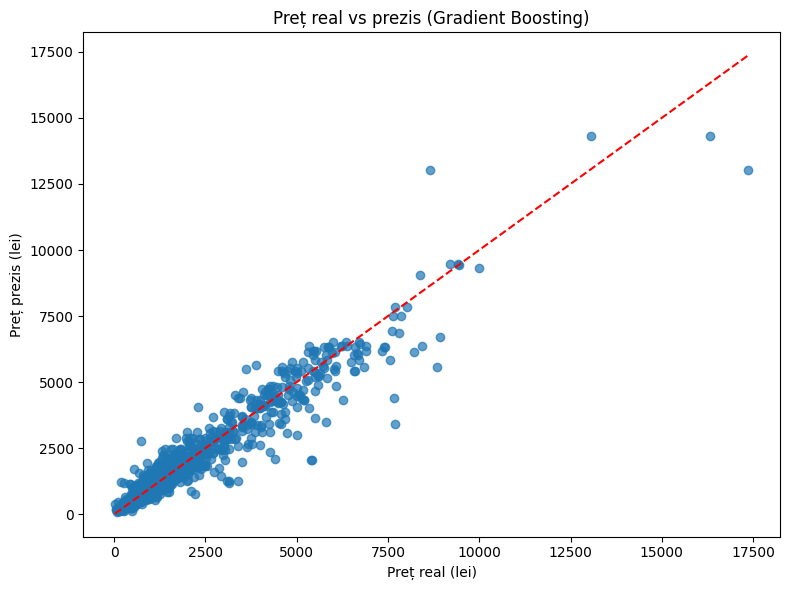

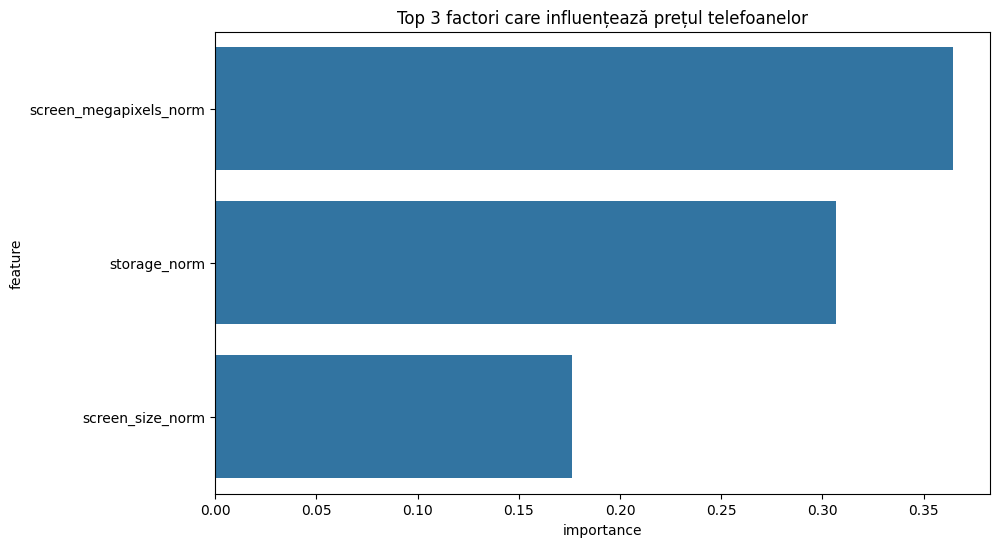

🔄 CROSS-VALIDATION (5-fold):
R² per fold: [0.72868268 0.66151879 0.8387834  0.65729711 0.7470966 ]
R² mediu: 0.7267
Std dev: 0.0664

--- Linear Regression ---
MAE: 818.679246001484
RMSE: 1057.8471204956497
R² train: 0.6047845545958592
R² test: 0.6186476442223399
🔹 Telefoane subevaluate:
    brand_original     price  Linear Regression_pred     diferenta
372        Samsung  16332.58             4419.038028 -11913.541972
260          Honor  17369.39             5916.581442 -11452.808558
289        Samsung  13068.00             4419.038028  -8648.961972
206           Poco   7598.39             2231.423972  -5366.966028
230        Samsung   9425.42             4343.898752  -5081.521248
286        Samsung   9189.19             4343.898752  -4845.291248
679       Motorola   7657.24             2873.309552  -4783.930448
579        Samsung   7696.00             3162.970177  -4533.029823
377        Samsung   8384.00             3857.518085  -4526.481915
394          Honor   9999.99             5

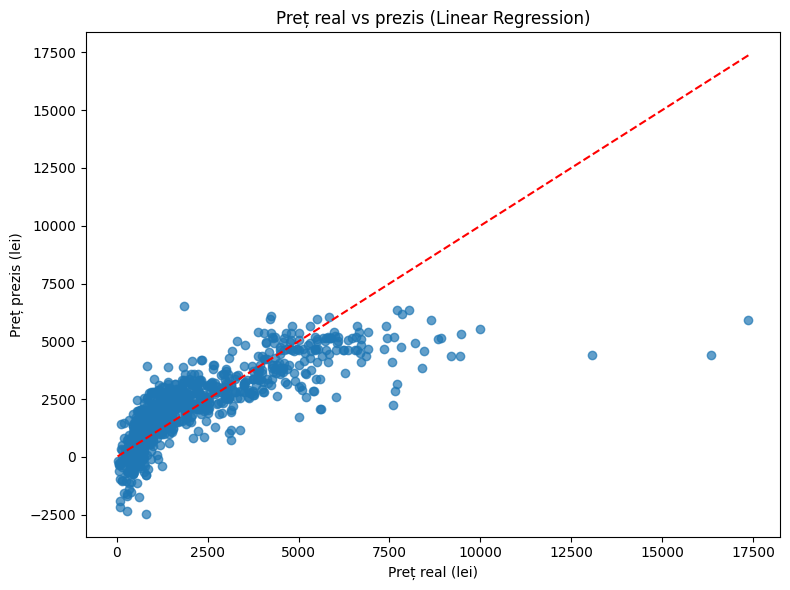

🔄 CROSS-VALIDATION (5-fold):
R² per fold: [0.30518183 0.37995409 0.63455057 0.61381512 0.41994777]
R² mediu: 0.4707
Std dev: 0.1308

--- HistGradient Boosting ---
MAE: 503.51780746023513
RMSE: 842.690985493693
R² train: 0.949109250567252
R² test: 0.7579989148161781
🔹 Telefoane subevaluate:
    brand_original     price  HistGradient Boosting_pred    diferenta
260          Honor  17369.39                11875.851286 -5493.538714
372        Samsung  16332.58                12391.354716 -3941.225284
579        Samsung   7696.00                 4030.916517 -3665.083483
299        Samsung   8835.00                 5364.027407 -3470.972593
679       Motorola   7657.24                 4489.074399 -3168.165601
267        Samsung   5428.53                 2653.357291 -2775.172709
245        Samsung   5399.99                 2658.037237 -2741.952763
704         Huawei   5499.45                 2802.335974 -2697.114026
966            One   4264.48                 2253.846038 -2010.633962
426      

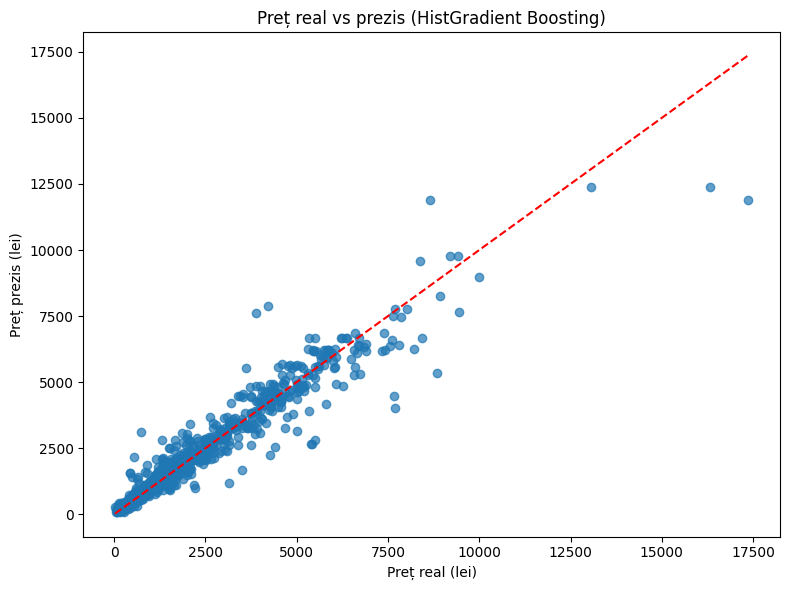

🔄 CROSS-VALIDATION (5-fold):
R² per fold: [0.74884297 0.65865368 0.80057263 0.77815541 0.68845099]
R² mediu: 0.7349
Std dev: 0.0536


In [29]:
# --- Modele ML ---
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    "Linear Regression": LinearRegression(),
    "HistGradient Boosting": HistGradientBoostingRegressor(max_iter=200, random_state=42),
}

results = []

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    df_model[name + "_pred"] = model.predict(X)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R²": r2})

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R² train:", model.score(X_train, y_train))
    print("R² test:", model.score(X_test, y_test))

    # Diferența între preț prezis și real
    df_model['diferenta'] = df_model[name + "_pred"] - df_model['price']

    # Telefoane subevaluate/supraevaluate
    subevaluate = df_model.sort_values('diferenta').head(10)
    supraevaluate = df_model.sort_values('diferenta', ascending=False).head(10)

    print("🔹 Telefoane subevaluate:")
    print(subevaluate[['brand_original', 'price', name + "_pred", 'diferenta']])
    print("🔹 Telefoane supraevaluate:")
    print(supraevaluate[['brand_original', 'price', name + "_pred", 'diferenta']])

    # Plot preț real vs prezis
    plt.figure(figsize=(8, 6))
    plt.scatter(df_model['price'], df_model[name + "_pred"], alpha=0.7)
    plt.plot([df_model['price'].min(), df_model['price'].max()],
             [df_model['price'].min(), df_model['price'].max()],
             color='red', linestyle='--')
    plt.title(f"Preț real vs prezis ({name})")
    plt.xlabel("Preț real (lei)")
    plt.ylabel("Preț prezis (lei)")
    plt.tight_layout()
    plt.show()

    if name != "Linear Regression" and name != "HistGradient Boosting":
        importances = model.feature_importances_
        features = X.columns
        feat_importance_df = pd.DataFrame({'feature': features, 'importance': importances})
        feat_importance_df = feat_importance_df.sort_values(by='importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=feat_importance_df.head(3))
        plt.title("Top 3 factori care influențează prețul telefoanelor")
        plt.show()

    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    print("=" * 60)
    print("🔄 CROSS-VALIDATION (5-fold):")
    print("=" * 60)
    print(f"R² per fold: {cv_scores}")
    print(f"R² mediu: {cv_scores.mean():.4f}")
    print(f"Std dev: {cv_scores.std():.4f}")
    print("=" * 60)

     # Interpretare
    if cv_scores.mean() > 0.90 and cv_scores.std() < 0.05:
        print("✅ MODEL EXCELENT ȘI CONSISTENT!")
    elif cv_scores.mean() > 0.85:
        print("✅ MODEL FOARTE BUN!")
    elif cv_scores.std() > 0.15:
        print("⚠️ Variație mare între folduri - instabil")

#### Diferența între preț prezis și real

### Interpretare

In [30]:
# --- Rezumat metrici ---
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== Comparatie modele ===")
print(results_df)


=== Comparatie modele ===
                   Model         MAE         RMSE        R²
0          Random Forest  453.002444   786.113317  0.789404
3  HistGradient Boosting  503.517807   842.690985  0.757999
1      Gradient Boosting  514.606369   848.595114  0.754596
2      Linear Regression  818.679246  1057.847120  0.618648
